In [5]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure, create_multifigure,
    plot_colormap_multifigure, plot_line_multifigure,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.utils.array_utils import derivative, resample
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE

# searching for all simulations in the batch
PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'

T_STOP = 120.0
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f't_stop={T_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)

# selecting a subset of simulations within the batch
PARAMS_SUBSET = SYSTEM_A_REFERENCE.replace(sr=0.2)

simulations = GridSimulationFromNPZ.dict_from_dir_paths(
    ('Ra', 'Da'), 
    sim_dir_paths,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_SUBSET,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)

# utilities for plotting
PARAM_REPR = lambda p: int(p) if isinstance(p, float) and float.is_integer(p) else p
save_figure = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='Ra_Da', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [ ]:
print('Before parameter selection')
for i in sim_dir_paths: print(i)
print('After parameter selection')
for i in simulations.values(): print(i.dir_path)

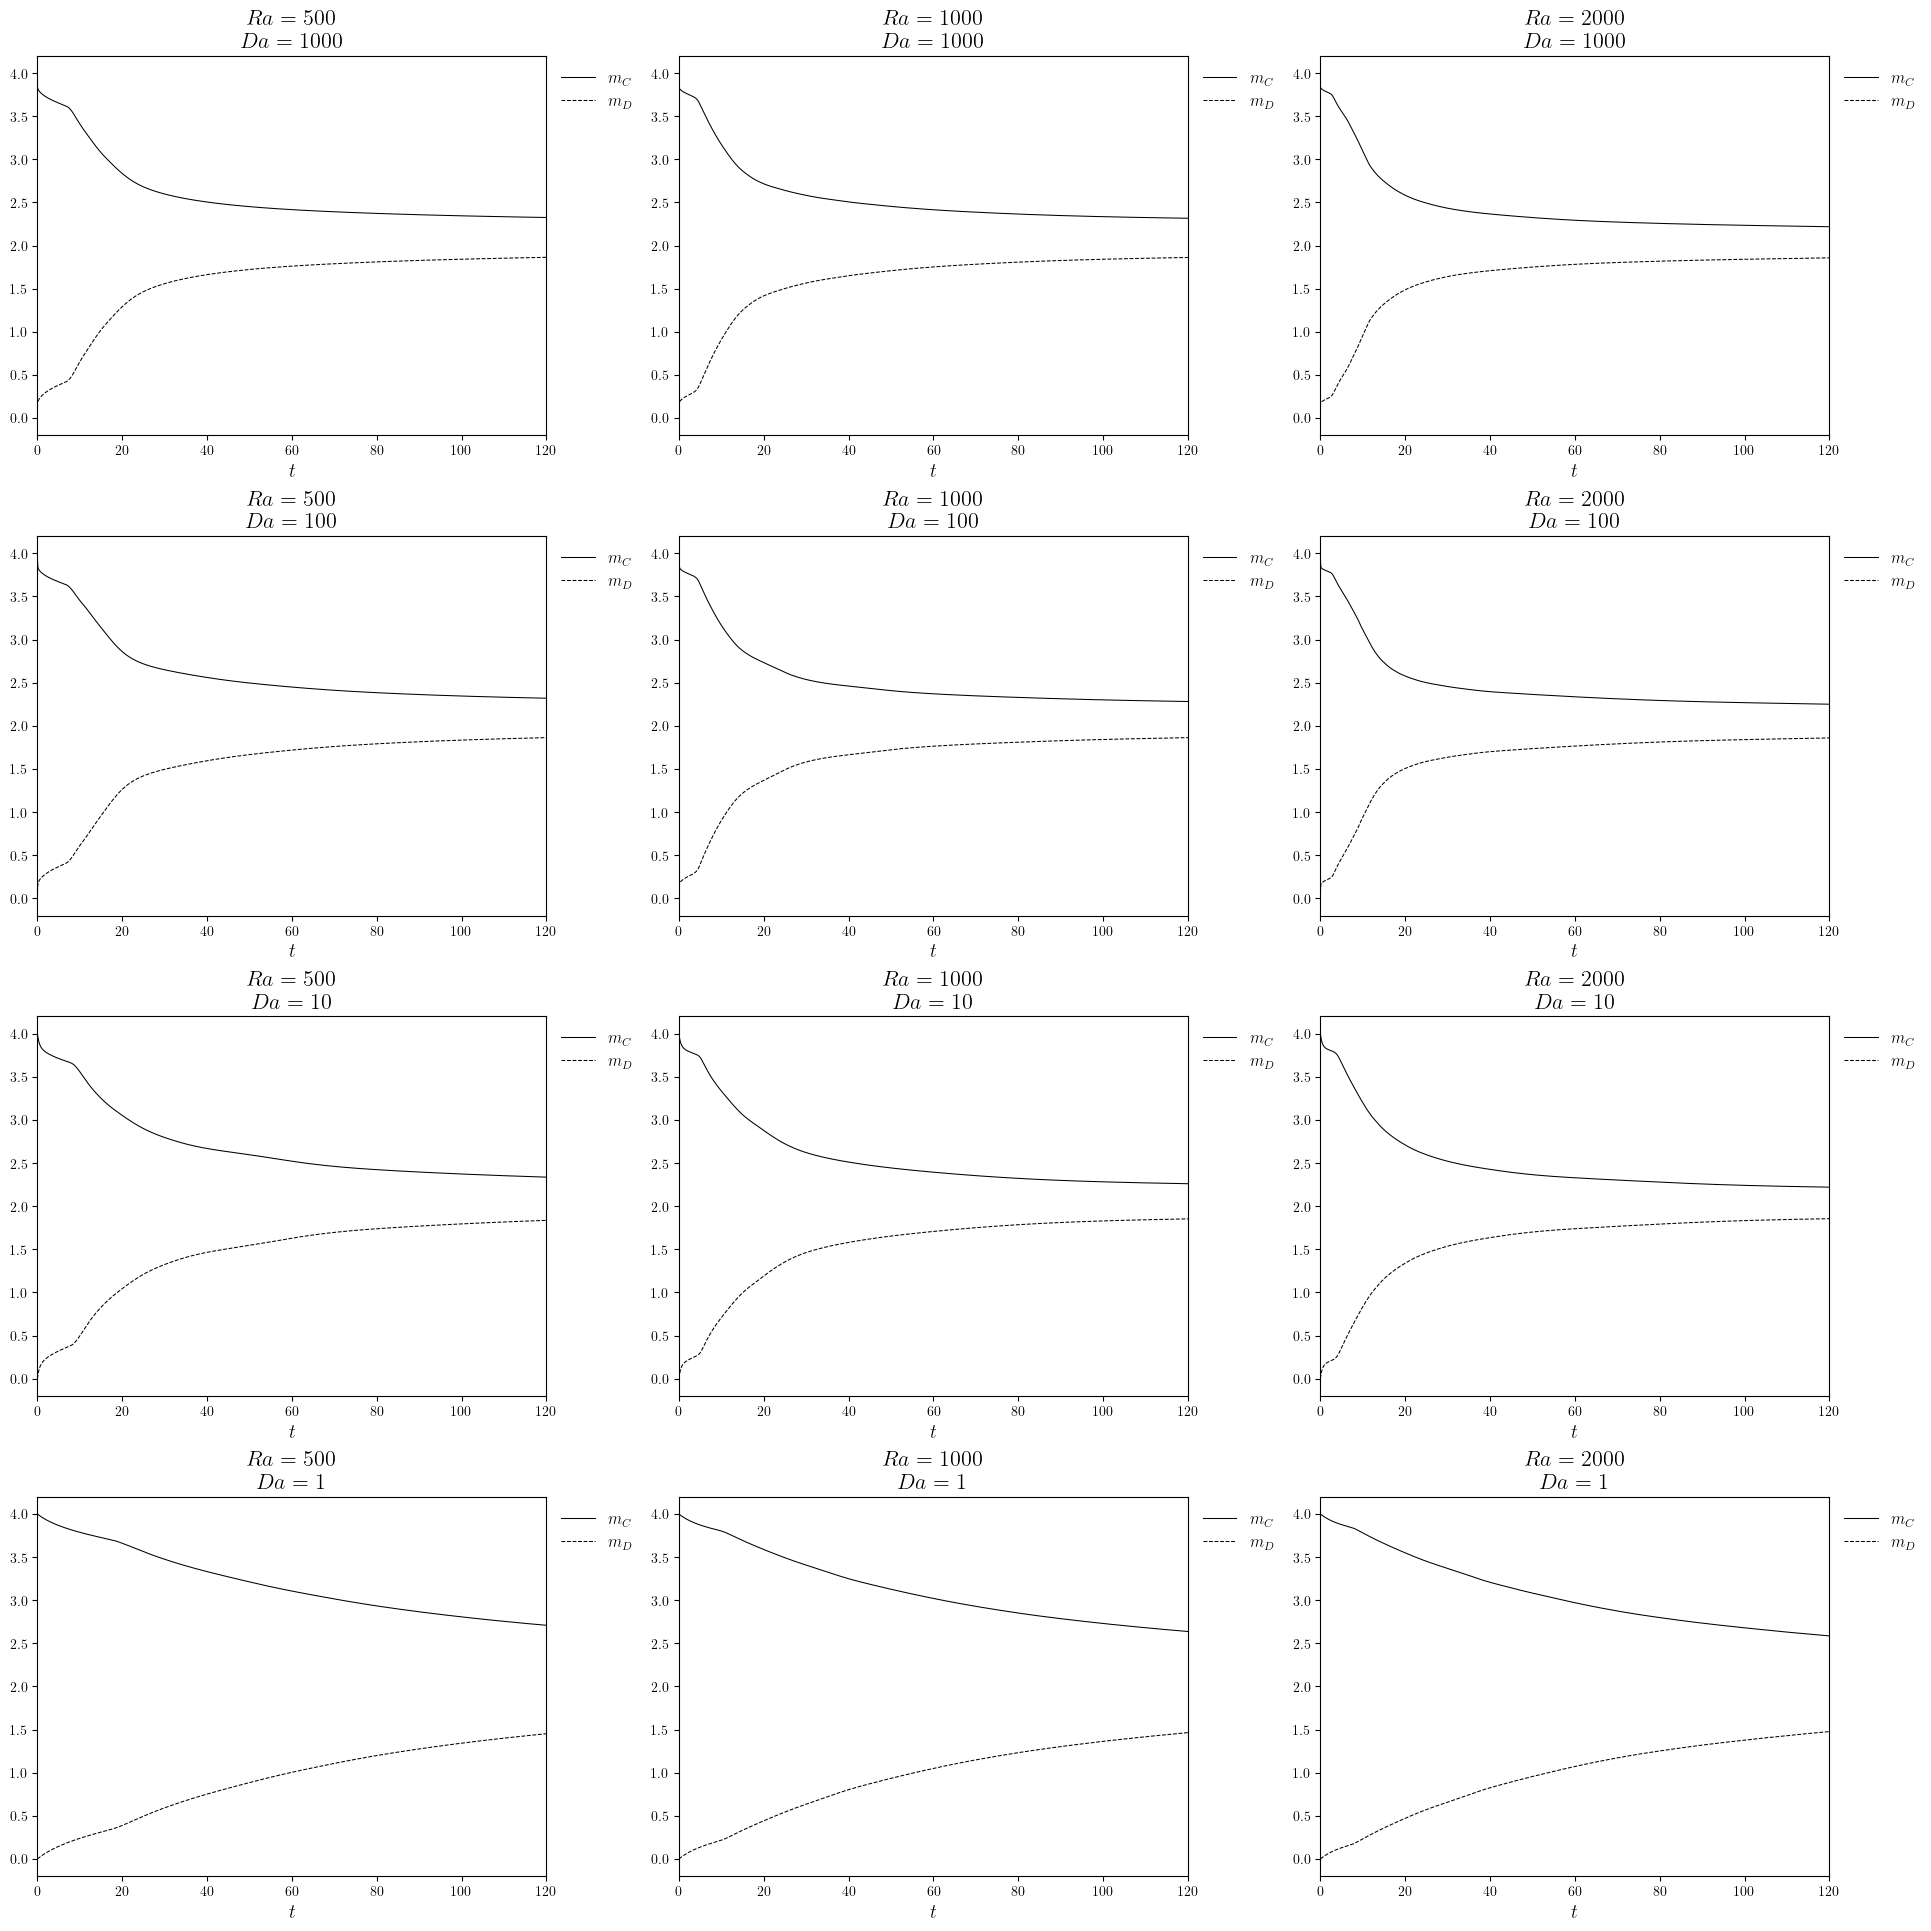

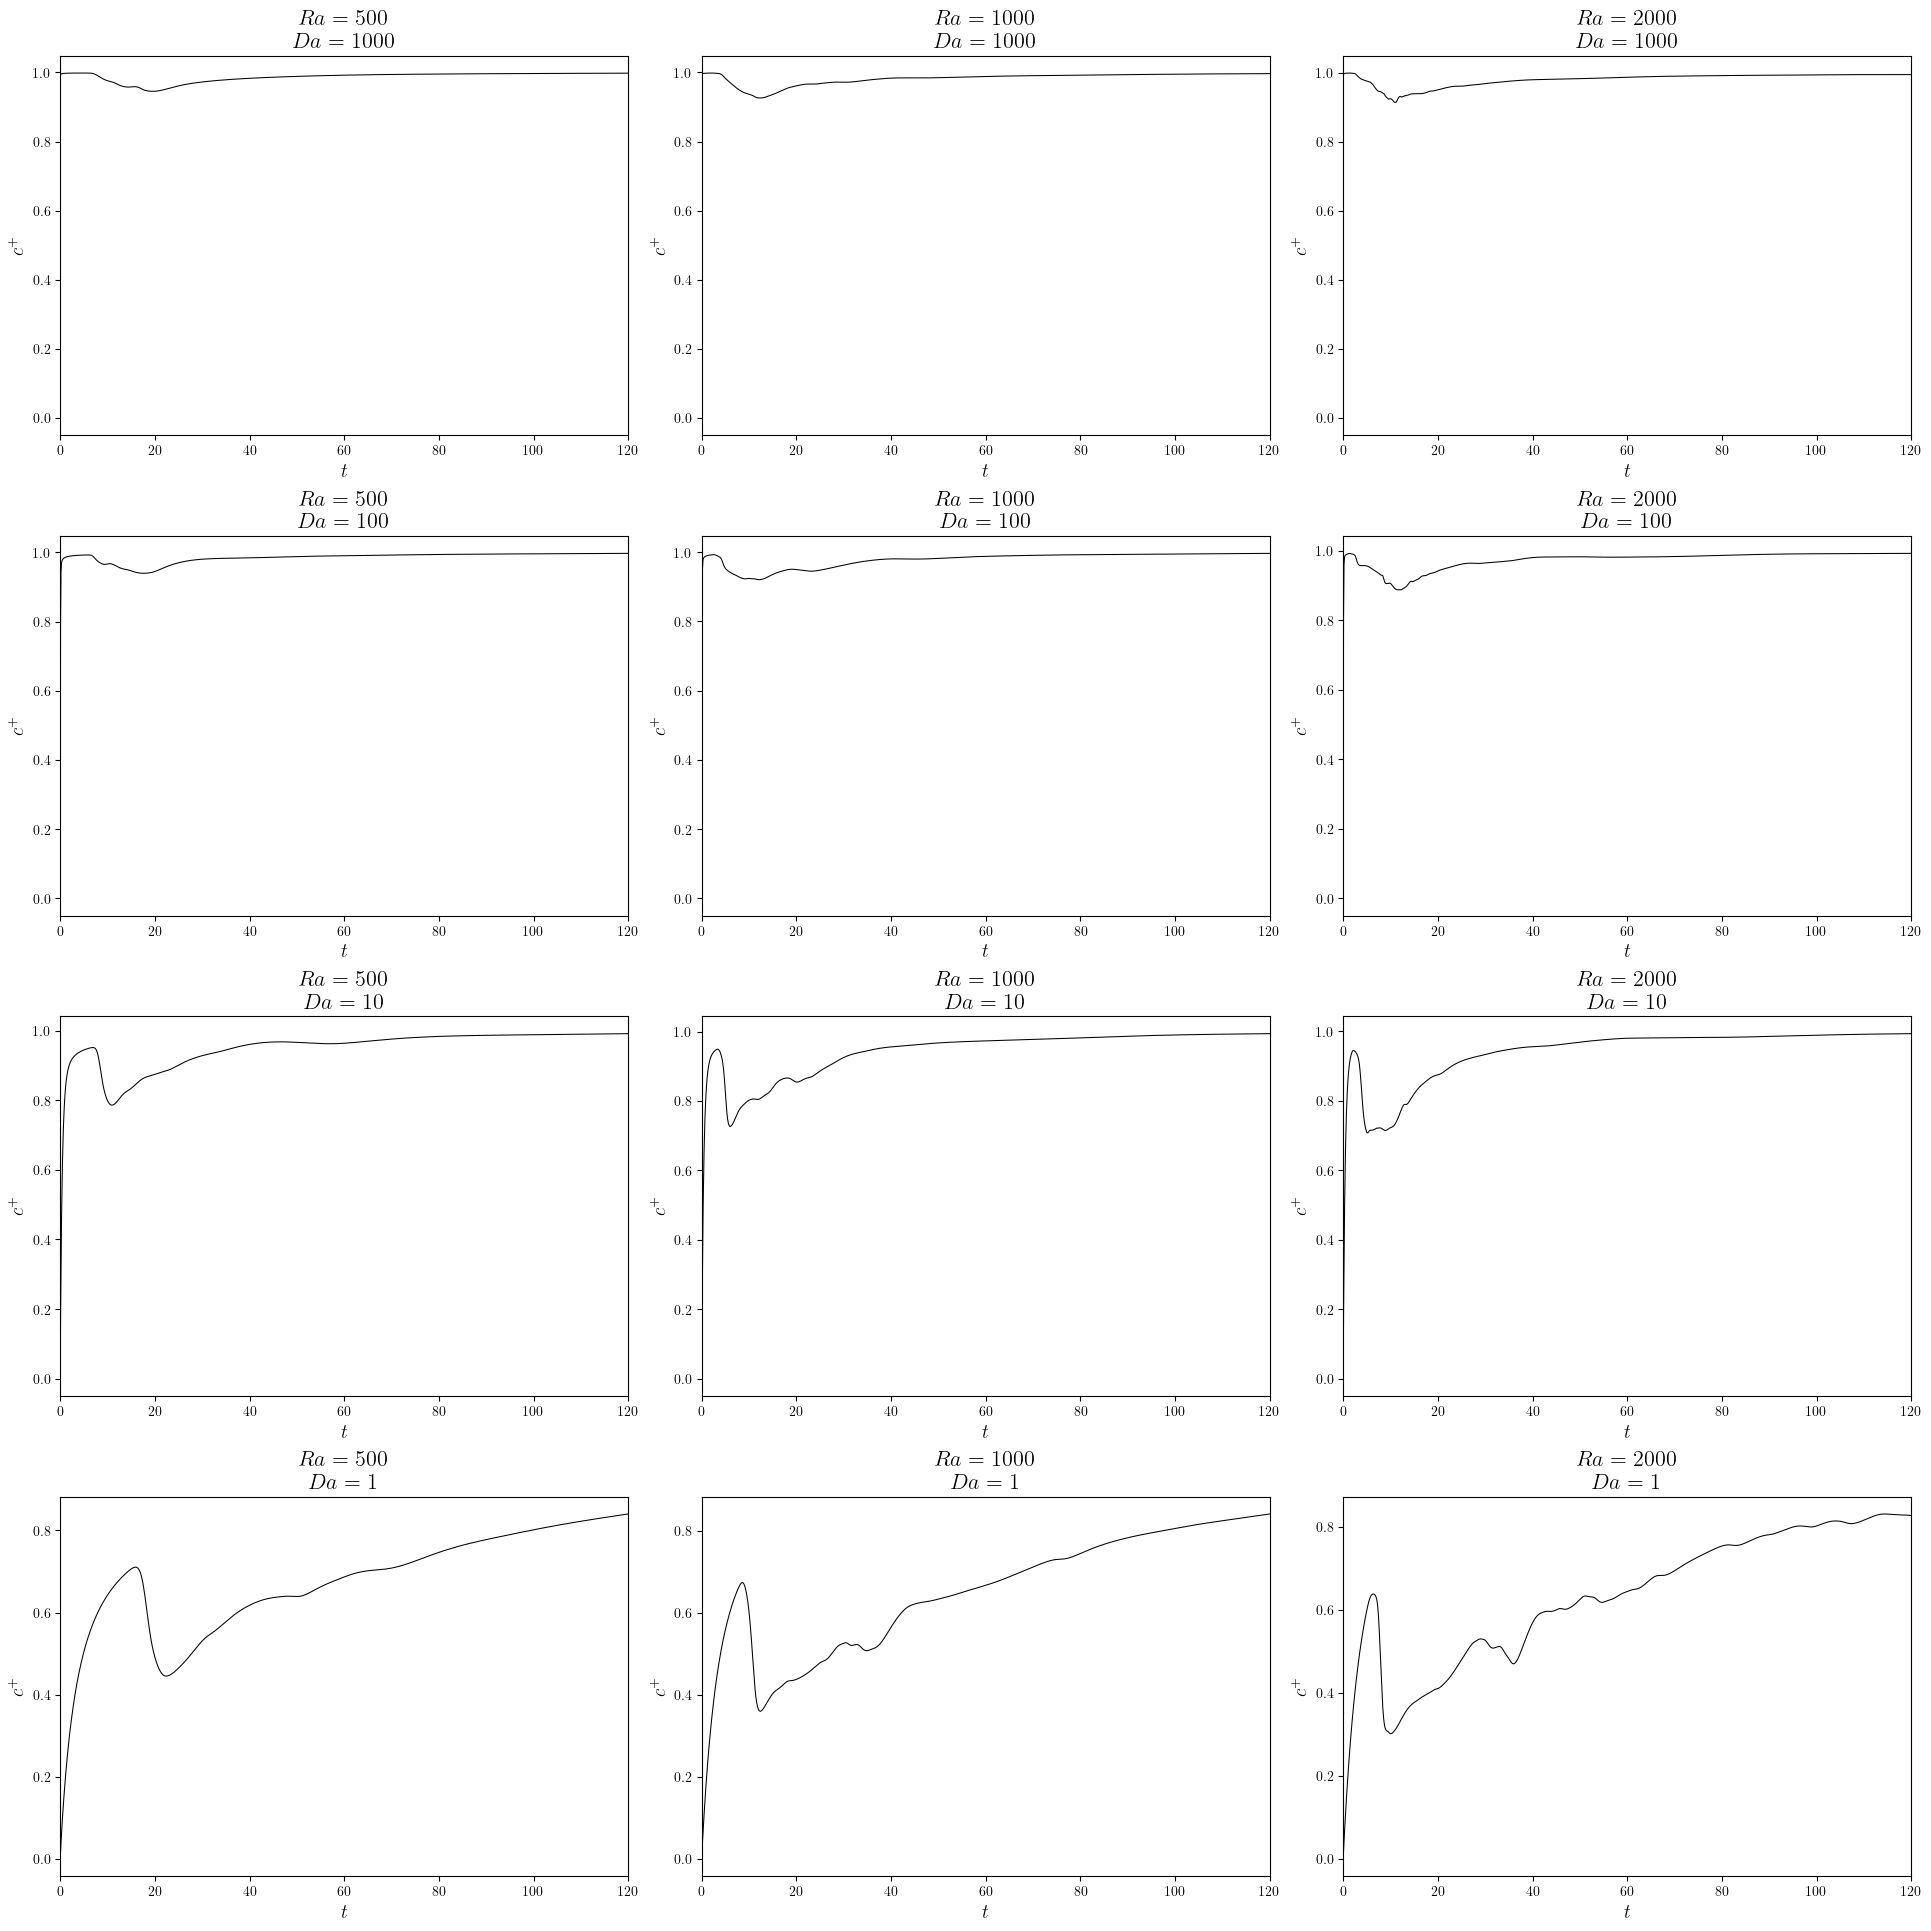

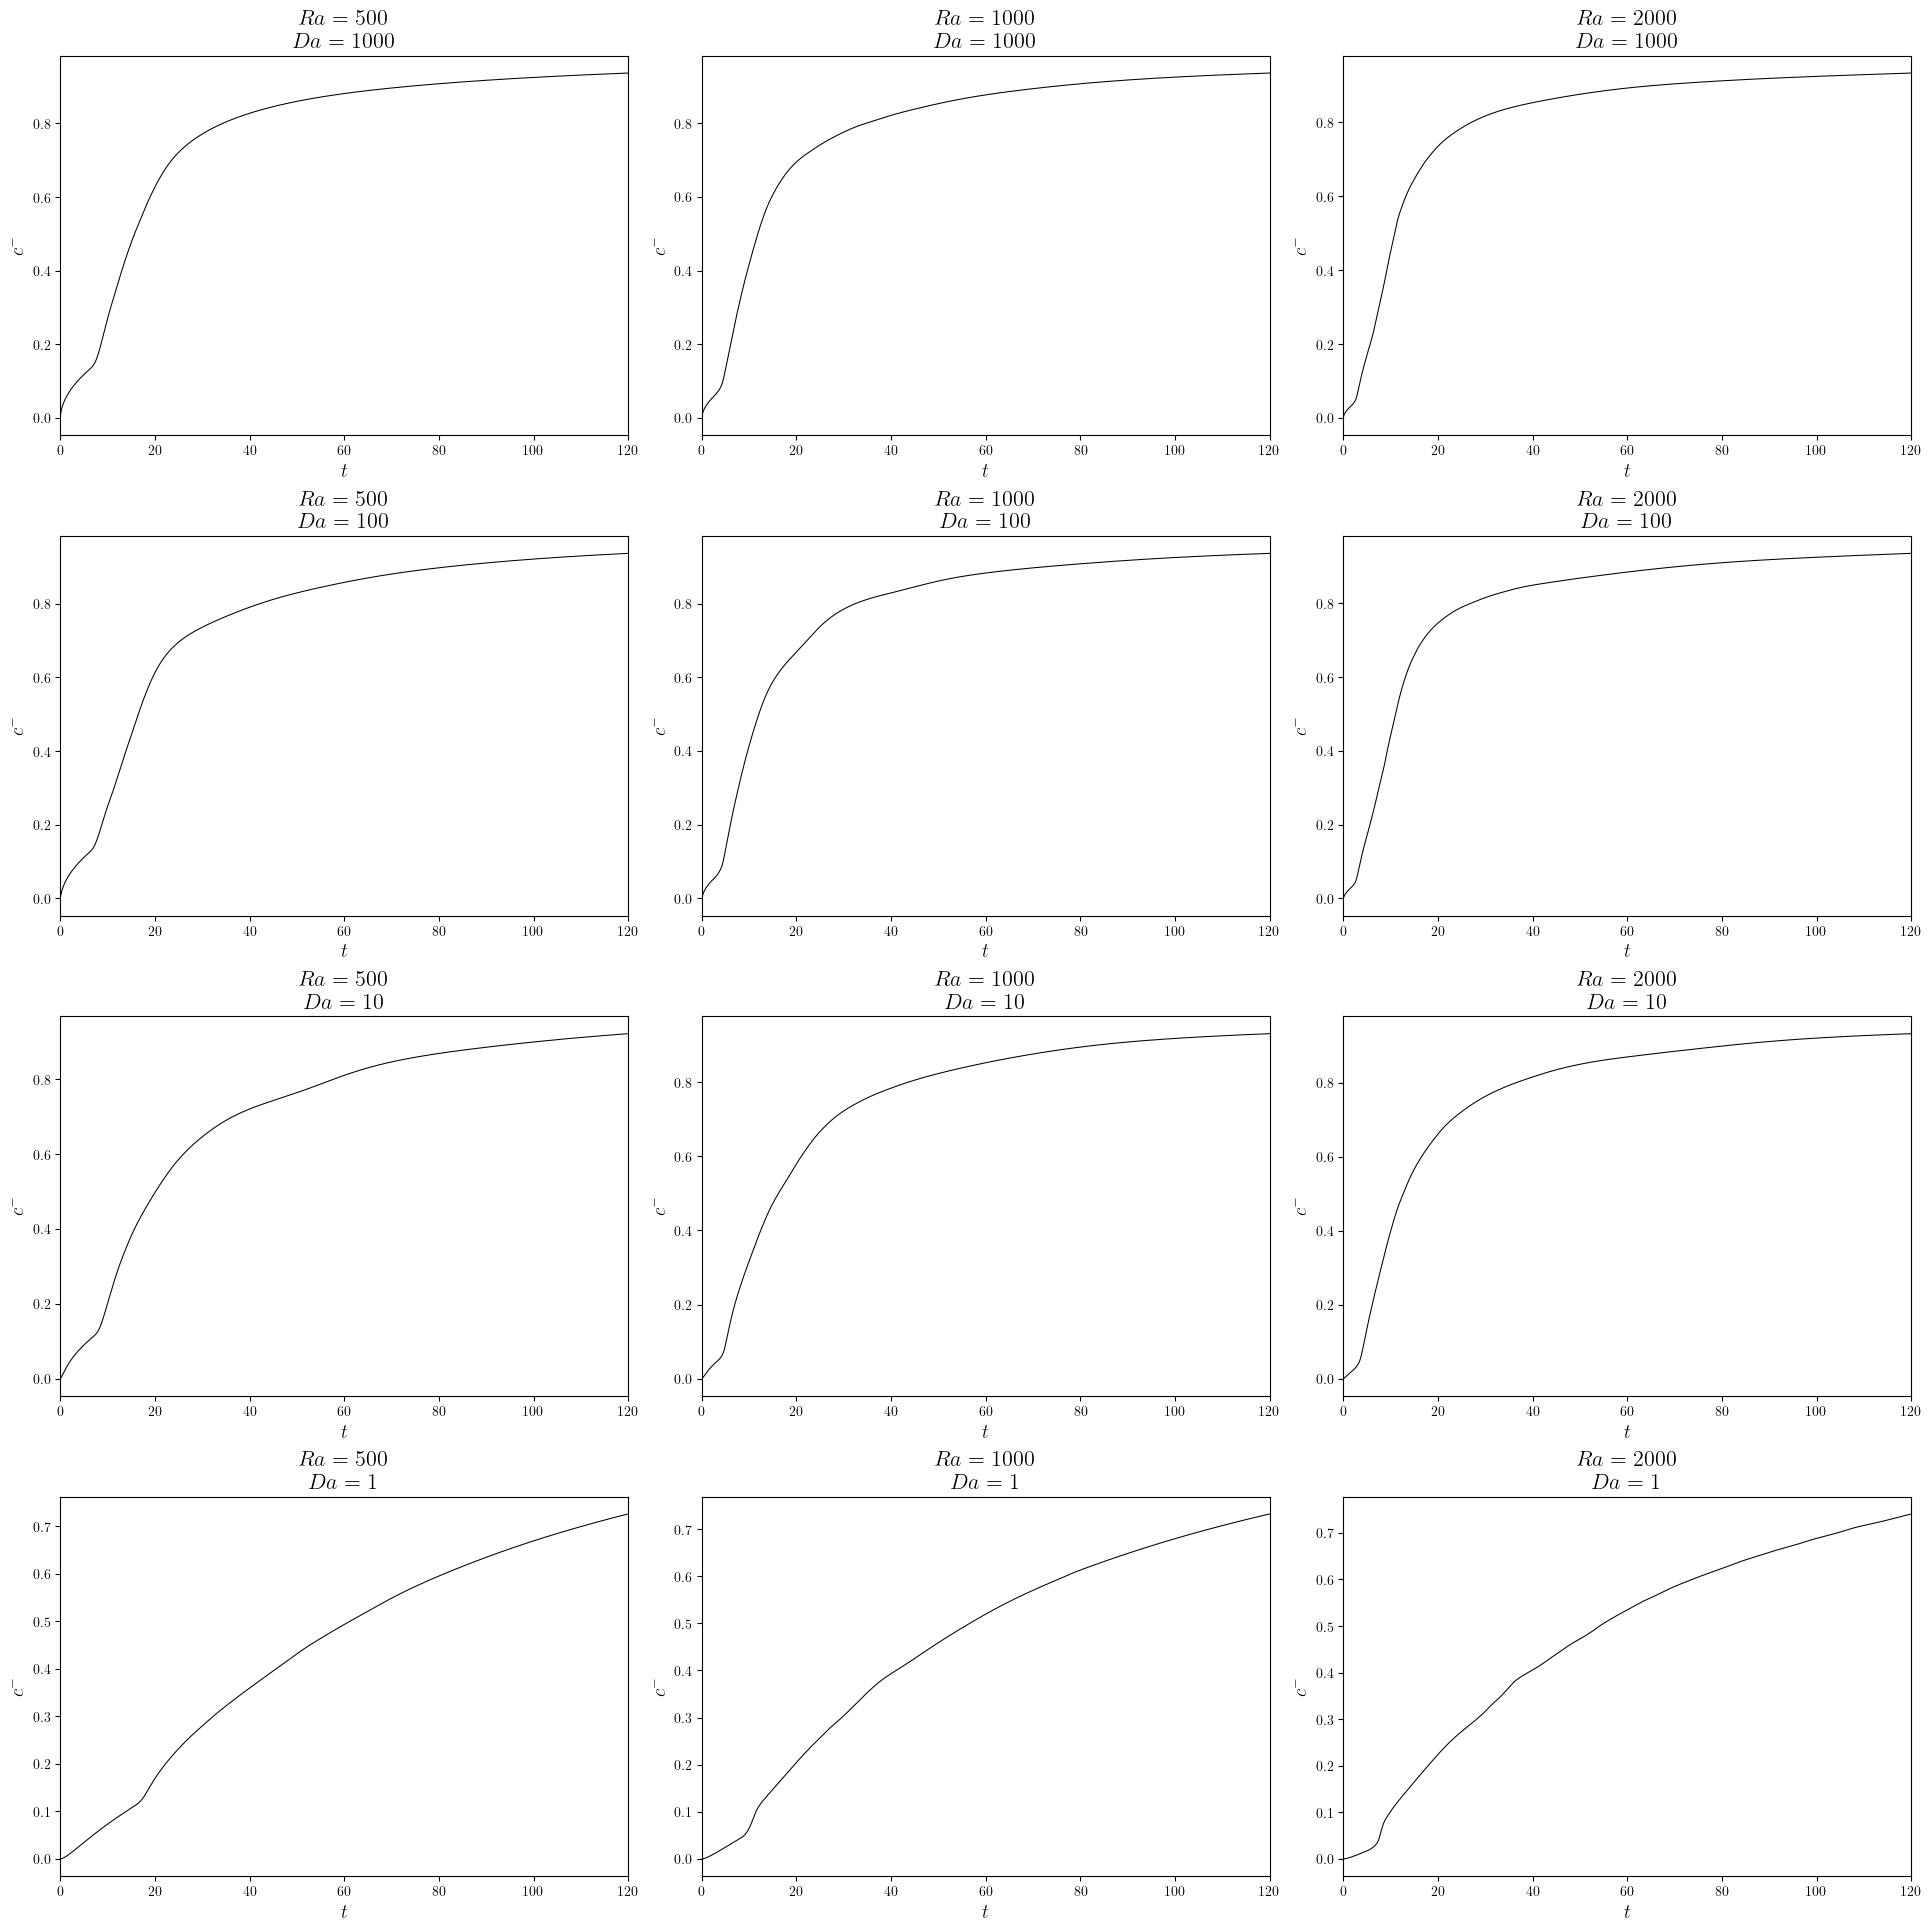

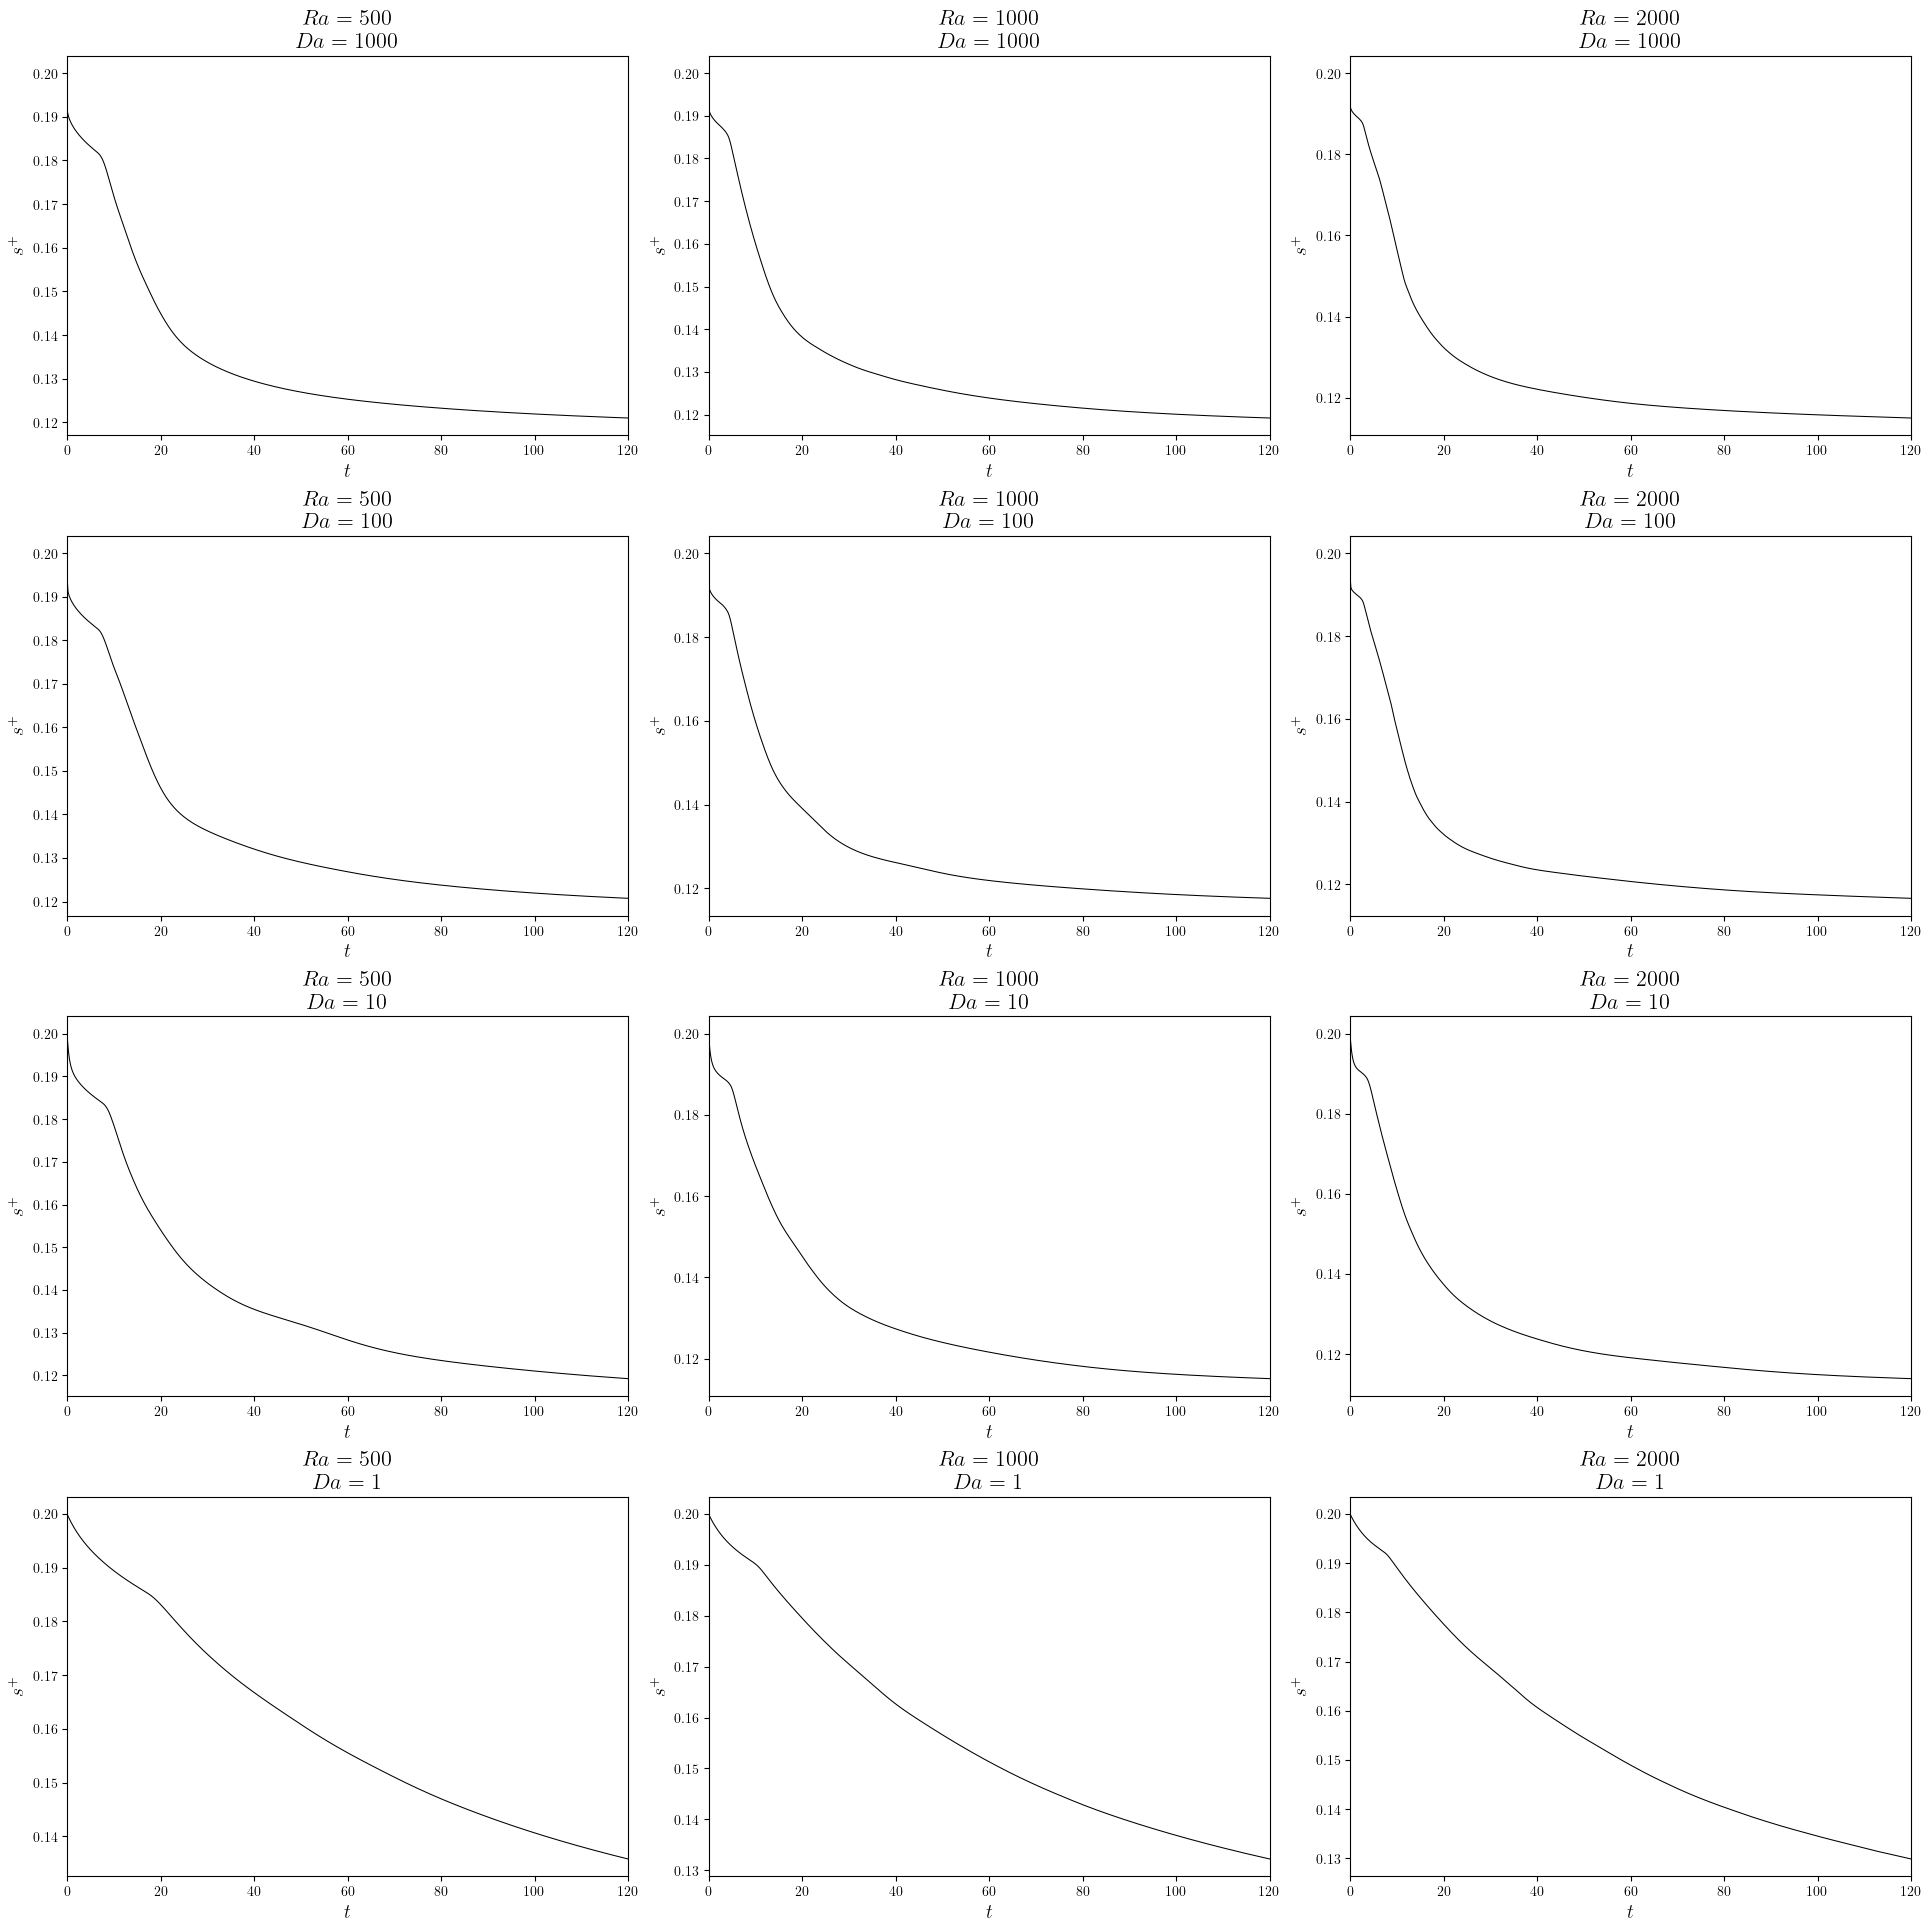

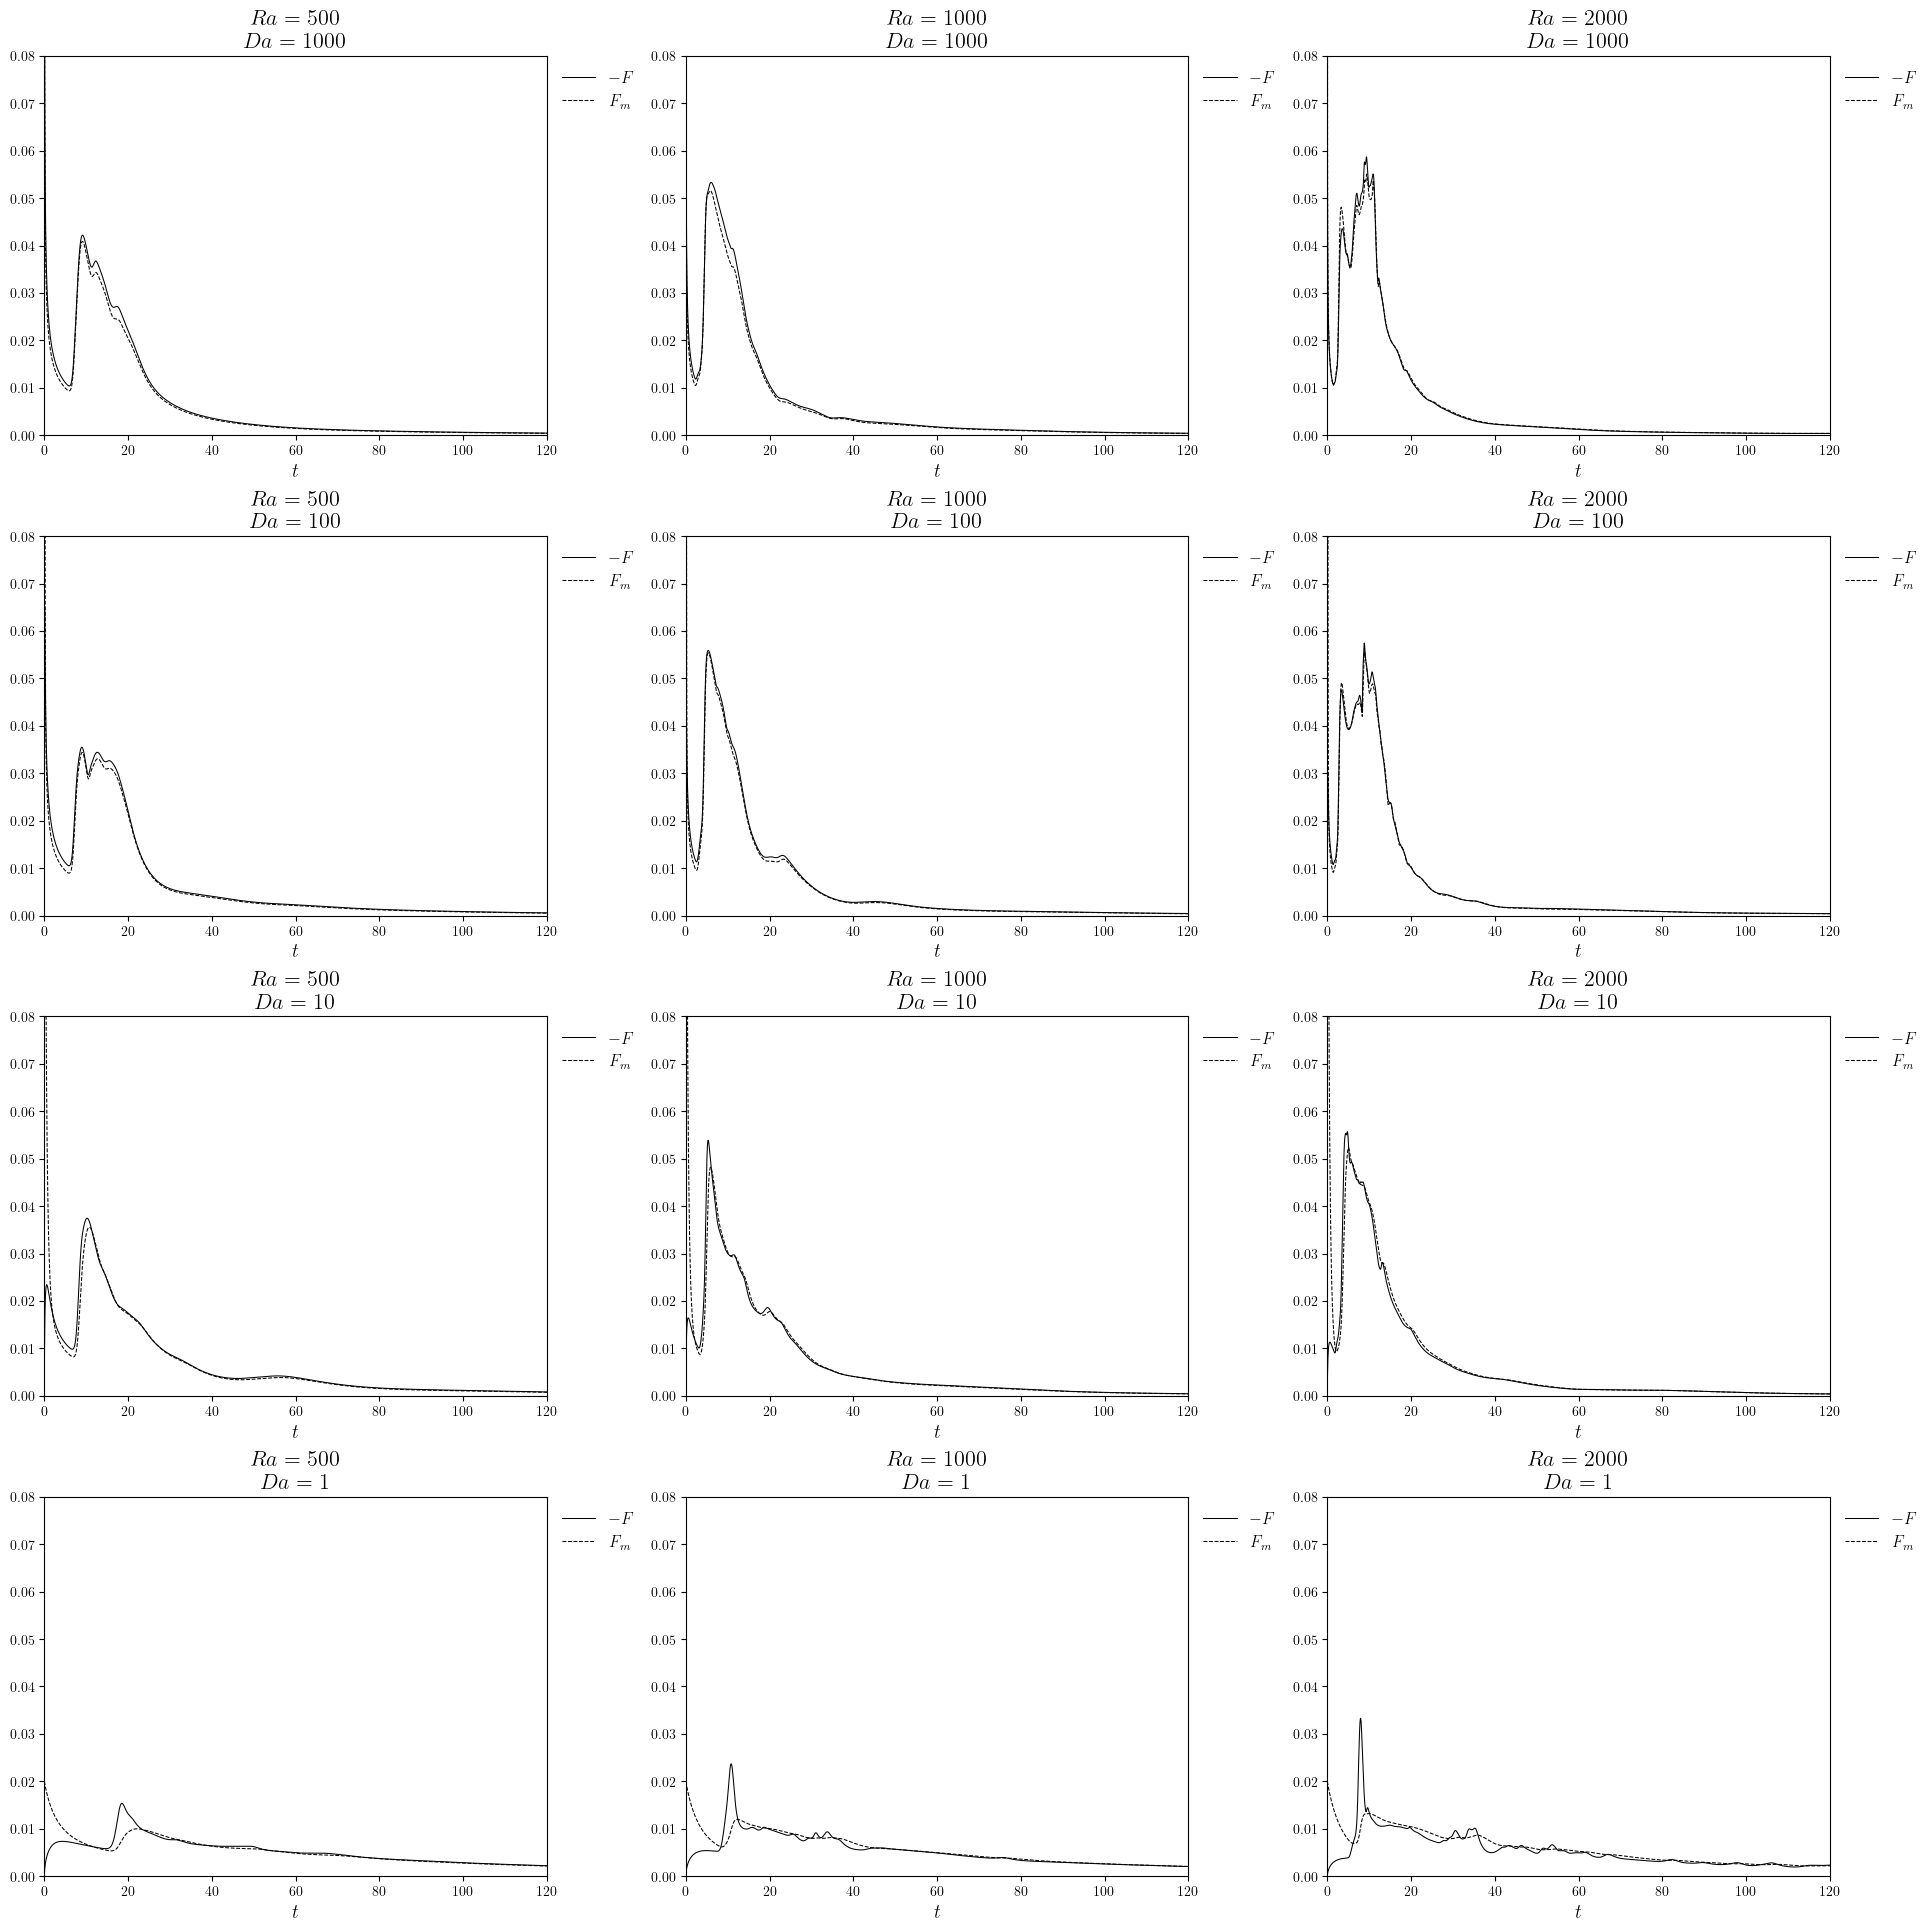

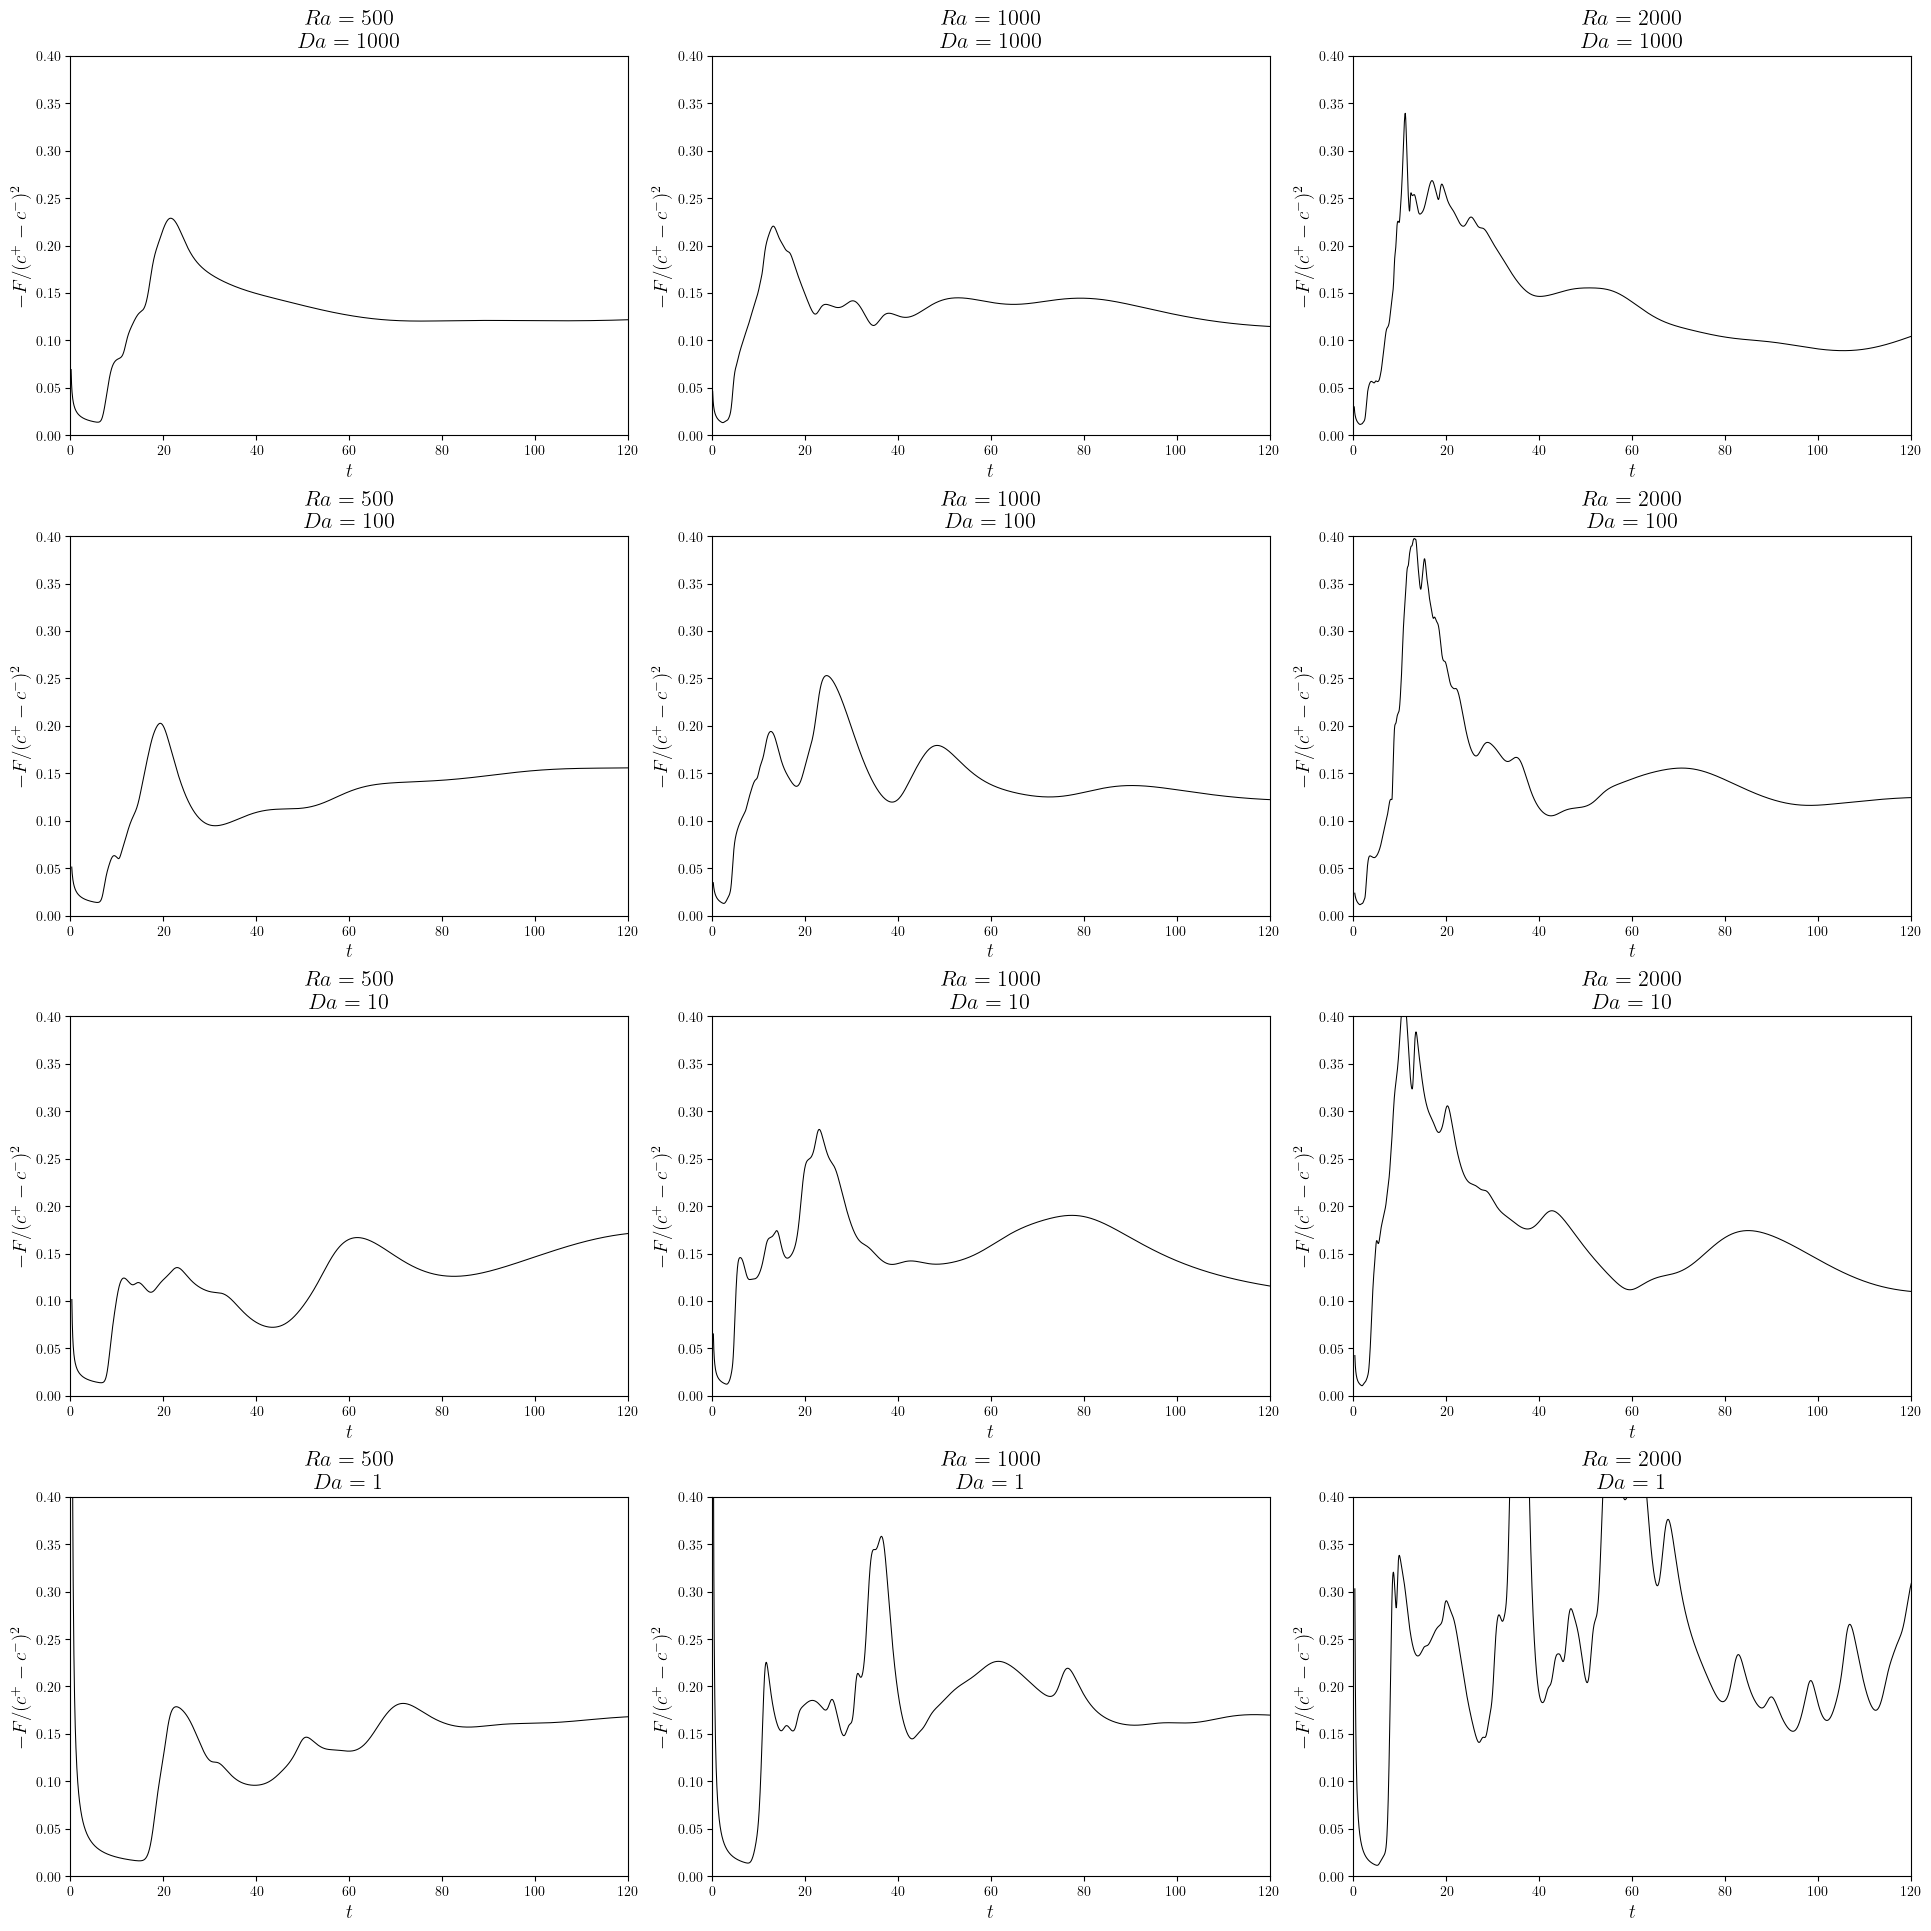

: 

In [ ]:
t_targets = (1.0, 3.0, 6.0, 9.0)
Ra_targets = (500.0, 1000.0, 2000.0)
Da_targets = (1.0, 10.0, 100.0, 1000.0)
include = lambda prm, trgs: prm in trgs if trgs else True

simulations_incl = {
    (Ra, Da): v for (Ra, Da), v in simulations.items()
    if include(Ra, Ra_targets) and include(Da, Da_targets)
}

fMax = 0.08
fRatioDash = 0.1
fRatioMax = 0.4
fRatio_expnt = 2
fRatio_slc = slice(10, None)

time_window = (0, 120)
n_cols = len(Ra_targets)
n_rows = int(len(simulations_incl) / len(Ra_targets))
mfig_mCmD, axs_mCmD, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)
mfig_cPlus, axs_cPlus, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)
mfig_cMinus, axs_cMinus, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)
mfig_sPlus, axs_sPlus, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)
mfig_fMass, axs_fMass, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)
mfig_fRatio, axs_fRatio, _ = create_multifigure(n_cols=n_cols, n_rows=n_rows)

imap = lambda ix, iy: int(n_rows - 1 - iy) * n_cols + ix
for (Ra, Da), sim in simulations_incl.items():
    Ra_index = Ra_targets.index(Ra)
    Da_index = Da_targets.index(Da)
    idx = imap(Ra_index, Da_index)
    ttl = f'$Ra={PARAM_REPR(Ra)}$\n$Da={PARAM_REPR(Da)}$'
    kws = dict(title=ttl, x_label='$t$', x_lims=time_window)
    zeta0, aspect = sim['zeta0', 'aspect']
    Lx = aspect * 1
    s, c, mC, mD, f, uRMS = sim['s', 'c', 'mC', 'mD', 'f', 'uRMS']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    zeta0_index = as_index(c.mesh.y_axis, zeta0)
    slcPlus = slice(zeta0_index, None)
    slcMinus = slice(0, zeta0_index)
    cPlus = NPyConstantSeries(
        grid_average(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
    )
    cMinus = NPyConstantSeries(
        grid_average(c.series, ('x', 'y'), (':', slcMinus)), c.time_series, 'cMinus',
    )
    sPlus = NPyConstantSeries(
        grid_average(s.series, ('x', 'y'), (':', slcPlus)), s.time_series, 'sPlus',
    )
    plot_line(mfig_mCmD, axs_mCmD[idx],
        [(mC.time_series, mC.value_series), (mD.time_series, mD.value_series)],
        legend_labels=[f'$m_C$', '$m_D$'],
        **kws,
    )
    plot_line(mfig_cPlus, axs_cPlus[idx],
        (cPlus.time_series, cPlus.value_series),
        y_label=f'$c^+$',
        **kws,
    )
    plot_line(mfig_cMinus, axs_cMinus[idx],
        (cMinus.time_series, cMinus.value_series),
        y_label=f'$c^-$',
        **kws,
    )
    plot_line(mfig_sPlus, axs_sPlus[idx],
        (sPlus.time_series, sPlus.value_series),
        y_label=f'$s^+$',
        **kws,
    )
    fMass = -(1/Lx) * derivative(mC.value_series, mC.time_series)
    plot_line(
        mfig_fMass, axs_fMass[idx],
        [
            (fZeta0.time_series, [-np.sum(i) for i in fZeta0.value_series]), 
            (mC.time_series, fMass),
        ],
        y_lims=(0, fMax),
        legend_labels=['$-F$', '$F_m$'],
        **kws,
    )
    tFine = fZeta0.time_series
    cPlusFine = resample(cPlus.value_series, cPlus.time_series, tFine)
    cMinusFine = resample(cMinus.value_series, cMinus.time_series, tFine)
    fRatio = [
        -np.sum(flx) / (cp - cm)**fRatio_expnt 
        for flx, cp, cm in zip(fZeta0.value_series, cPlusFine, cMinusFine, strict=True)
    ]
    plot_line(mfig_fRatio, axs_fRatio[idx],
        (tFine[fRatio_slc], fRatio[fRatio_slc]),
        y_label=f'$-F/(c^+ - c^-)^{fRatio_expnt}$',
        y_lims=(0, fRatioMax),
        **kws,
    )

if DIR_FIGS:
    sr = PARAMS_SUBSET['sr']
    names = ('mCmD(t)', 'cPlus(t)', 'cMinus(t)', 'sPlus(t)', 'fMass(t)', 'fRatio(t)')
    mfigs = (mfig_mCmD, mfig_cPlus, mfig_cMinus, mfig_sPlus, mfig_fMass, mfig_fRatio)
    for name, mfig in zip(names, mfigs, strict=True):
        save_figure(f'sr={sr}_{name}')(mfig)